In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean and professional grid style for all plots
sns.set_theme(style="whitegrid")

# Load the feature-engineered dataset from Step 4
df = pd.read_csv('../data/engineered_rideshare.csv')

# Verify the data shape
print("Dataset Loaded Successfully! Shape:", df.shape)

Dataset Loaded Successfully! Shape: (286457, 65)


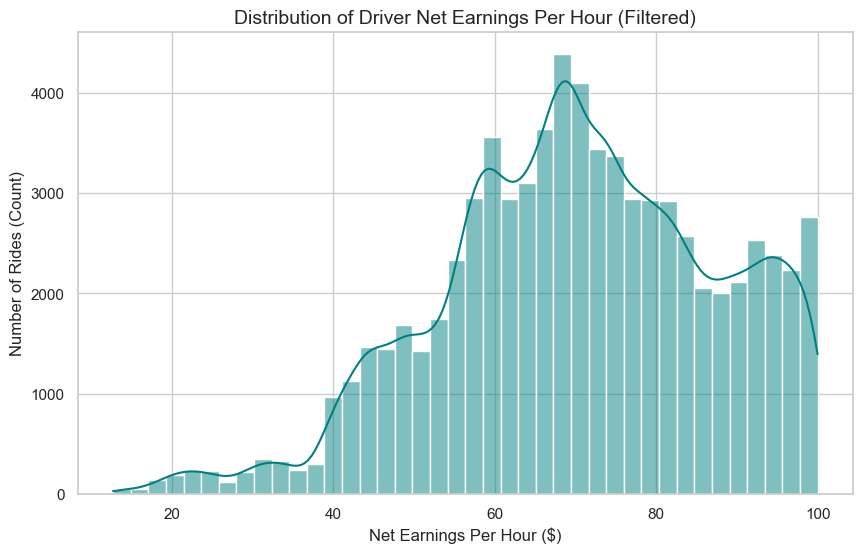

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Filter out extreme outliers to see the real distribution (Earning between $0 and $100)
df_plot = df[(df['driver_net_per_hour'] > 0) & (df['driver_net_per_hour'] <= 100)]

# Plot the histogram with updated filtered data
sns.histplot(data=df_plot, x='driver_net_per_hour', bins=40, kde=True, color='teal')

# Add business communication labels and titles
plt.title('Distribution of Driver Net Earnings Per Hour (Filtered)', fontsize=14)
plt.xlabel('Net Earnings Per Hour ($)', fontsize=12)
plt.ylabel('Number of Rides (Count)', fontsize=12)

plt.show()

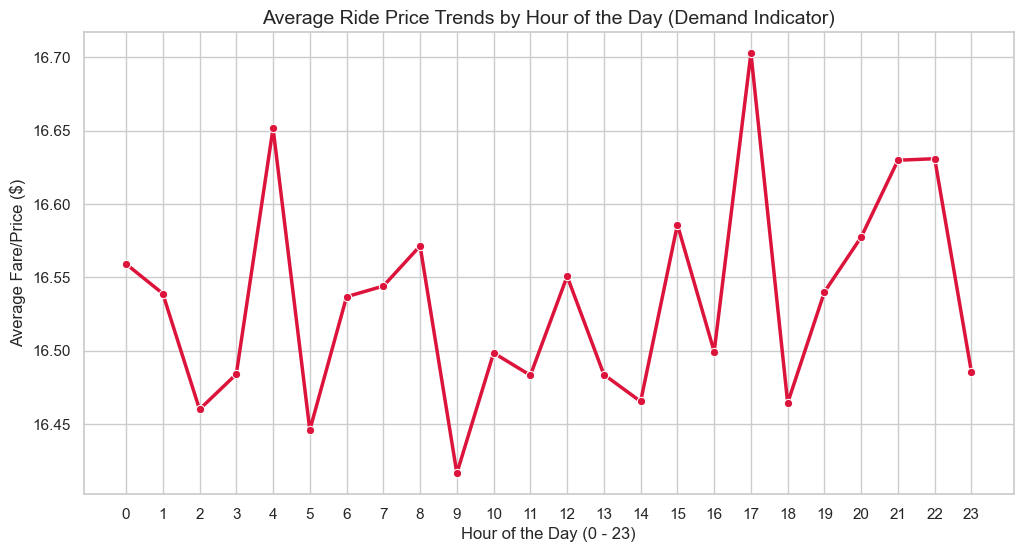

In [4]:
plt.figure(figsize=(12, 6))

# Plot the average price across different hours of the day
sns.lineplot(data=df, x='hour_of_day', y='price', estimator='mean', errorbar=None, marker='o', color='crimson', linewidth=2.5)

# Adding titles and labels
plt.title('Average Ride Price Trends by Hour of the Day (Demand Indicator)', fontsize=14)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12)
plt.ylabel('Average Fare/Price ($)', fontsize=12)
plt.xticks(range(0, 24))

plt.show()

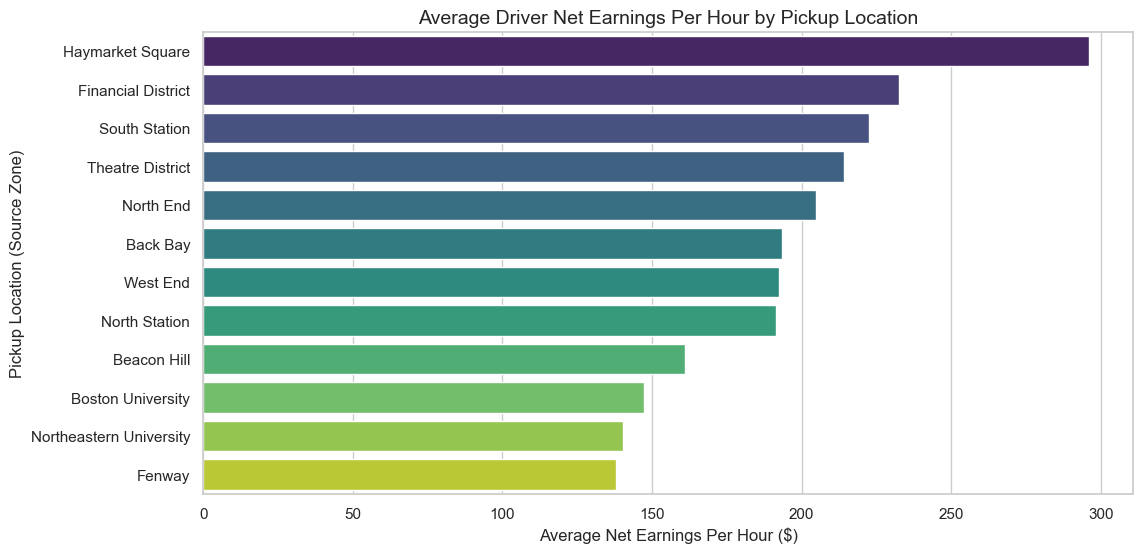

In [5]:
plt.figure(figsize=(12, 6))

# Calculate average net earnings per hour for each pickup location (source)
zone_earnings = df.groupby('source')['driver_net_per_hour'].mean().sort_values(ascending=False).reset_index()

# Plot a bar chart showing earnings by zone
sns.barplot(data=zone_earnings, x='driver_net_per_hour', y='source', hue='source', palette='viridis', legend=False)

# Adding titles and labels
plt.title('Average Driver Net Earnings Per Hour by Pickup Location', fontsize=14)
plt.xlabel('Average Net Earnings Per Hour ($)', fontsize=12)
plt.ylabel('Pickup Location (Source Zone)', fontsize=12)

plt.show()

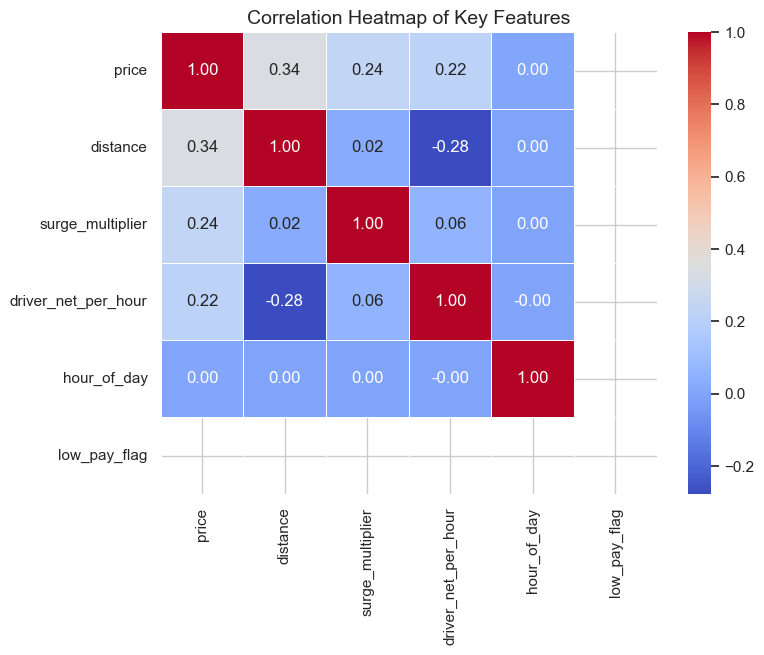

In [6]:
plt.figure(figsize=(8, 6))

# Select key numerical features to find correlations
features_to_check = ['price', 'distance', 'surge_multiplier', 'driver_net_per_hour', 'hour_of_day', 'low_pay_flag']
corr_matrix = df[features_to_check].corr()

# Plot a Heatmap to visualize correlation strengths
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Key Features', fontsize=14)
plt.show()